Spatial AI Framework for Ganga River Water Quality Prediction Using Multimodal Environmental Data and Graph Neural Networks

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

In [2]:
file_path = "Ganga_Multimodal_Spatial_WQ.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (500, 18)


,Latitude,Longitude,River_distance_km,rainfall,population_density,LULC,river_discharge,GHSL_built_distance,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L),Calcium (mg/L),Magnesium (mg/L),Sodium (mg/L),Chloride (mg/L),Sulphate (mg/L)
0,26.472200,80.378600,0.000000,126.637291,8584.025759,3,1236.489010,11.014173,6.119589,7.973308,242.613062,2.190912,0.746686,31.335365,23.629568,33.691278,43.859560,19.462579
1,26.469886,80.383865,0.583825,125.200150,8615.536671,3,1235.032578,11.033469,5.939339,7.994959,244.327825,2.218862,0.718096,32.206081,23.479450,33.693488,43.701966,19.942801
2,26.467572,80.389130,1.167660,128.025563,8422.276586,3,1225.769504,11.062408,5.920820,7.969674,239.175792,2.226437,0.725862,32.450311,23.393123,32.498674,43.303156,20.025801
3,26.465259,80.394395,1.751505,131.118663,8482.392869,3,1219.673132,11.100866,6.066897,7.989887,238.020327,2.287316,0.722788,33.018796,24.196596,33.815325,41.583460,20.461237
4,26.462945,80.399661,2.335359,126.313472,8373.801690,3,1254.608275,11.148678,6.068008,7.927495,236.020383,2.236926,0.710501,31.751909,23.949339,34.754299,42.531206,20.866321


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Latitude                       500 non-null    float64
 1   Longitude                      500 non-null    float64
 2   River_distance_km              500 non-null    float64
 3   rainfall                       500 non-null    float64
 4   population_density             500 non-null    float64
 5   LULC                           500 non-null    int64  
 6   river_discharge                500 non-null    float64
 7   GHSL_built_distance            500 non-null    float64
 8   Dissolved oxygen (mg/L)        500 non-null    float64
 9   Potential of Hydrogen (pH)     500 non-null    float64
 10  Total Dissolved Solids (mg/L)  500 non-null    float64
 11  Nitrate N (mgN/L)              500 non-null    float64
 12  Amonia N (mgN/L)               500 non-null    flo

In [4]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [5]:
df.describe()

,Latitude,Longitude,River_distance_km,rainfall,population_density,LULC,river_discharge,GHSL_built_distance,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L),Calcium (mg/L),Magnesium (mg/L),Sodium (mg/L),Chloride (mg/L),Sulphate (mg/L)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,25.894900,81.692250,146.052476,147.644563,1884.673806,2.320000,2541.103373,17.229479,7.725910,7.836751,253.734057,0.729439,0.155327,35.946826,18.025221,36.856934,43.743788,25.545949
std,0.334306,0.760716,84.688609,13.543468,2230.422598,0.866662,759.256185,2.279039,0.705269,0.235179,41.567115,0.333344,0.157457,8.984896,5.820484,7.145223,8.853752,8.274096
min,25.317600,80.378600,0.000000,122.645916,615.160298,1.000000,1219.673132,11.014173,5.891594,7.397834,191.333803,0.454597,0.045258,21.154341,8.924328,25.097447,28.301892,10.044646
25%,25.606250,81.035425,72.905014,135.556127,761.803807,2.000000,1973.651638,16.769566,7.189180,7.612022,219.870060,0.566164,0.074383,27.252433,12.227849,30.588852,36.216150,18.481296
50%,25.894900,81.692250,145.955837,147.398751,838.161150,2.000000,2347.027226,17.402669,7.817587,7.852090,245.970441,0.658711,0.087143,35.893946,17.882724,36.050091,42.683897,27.405429
75%,26.183550,82.349075,219.151042,159.518087,1365.439373,3.000000,3266.125673,19.000100,8.345850,8.056857,276.910636,0.719380,0.121428,44.298469,23.320453,42.805987,50.445090,32.398340
max,26.472200,83.005900,292.489195,174.937823,8989.303719,4.000000,3839.942307,19.999881,8.938434,8.273027,373.694361,2.287316,0.746686,50.493102,29.235585,51.600880,61.136225,37.763527


In [6]:
feature_cols = [
    'Latitude',
    'Longitude',
    'River_distance_km',
    'rainfall',
    'population_density',
    'LULC',
    'river_discharge',
    'GHSL_built_distance'
]

In [7]:
target_cols = [
    'Dissolved oxygen (mg/L)',
    'Potential of Hydrogen (pH)',
    'Total Dissolved Solids (mg/L)',
    'Nitrate N (mgN/L)',
    'Amonia N (mgN/L)'
]

In [8]:
X = df[feature_cols]

Y = df[target_cols]


print("Input Shape:", X.shape)
print("Target Shape:", Y.shape)

Input Shape: (500, 8)
Target Shape: (500, 5)


In [9]:
X = pd.get_dummies(
    X,
    columns=['LULC'],
    prefix='LULC'
)

X.head()

,Latitude,Longitude,River_distance_km,rainfall,population_density,river_discharge,GHSL_built_distance,LULC_1,LULC_2,LULC_3,LULC_4
0,26.472200,80.378600,0.000000,126.637291,8584.025759,1236.489010,11.014173,False,False,True,False
1,26.469886,80.383865,0.583825,125.200150,8615.536671,1235.032578,11.033469,False,False,True,False
2,26.467572,80.389130,1.167660,128.025563,8422.276586,1225.769504,11.062408,False,False,True,False
3,26.465259,80.394395,1.751505,131.118663,8482.392869,1219.673132,11.100866,False,False,True,False
4,26.462945,80.399661,2.335359,126.313472,8373.801690,1254.608275,11.148678,False,False,True,False


In [10]:
scaler_X = StandardScaler()

X_scaled = scaler_X.fit_transform(X)


X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Latitude,Longitude,River_distance_km,rainfall,population_density,river_discharge,GHSL_built_distance,LULC_1,LULC_2,LULC_3,LULC_4
0,1.728590,-1.728590,-1.726309,-1.552653,3.006633,-1.720000,-2.729892,-0.369274,-1.189731,2.399324,-0.413473
1,1.721662,-1.721662,-1.719409,-1.658873,3.020775,-1.721921,-2.721416,-0.369274,-1.189731,2.399324,-0.413473
2,1.714734,-1.714734,-1.712508,-1.450046,2.934040,-1.734133,-2.708706,-0.369274,-1.189731,2.399324,-0.413473
3,1.707806,-1.707806,-1.705607,-1.221434,2.961020,-1.742170,-2.691814,-0.369274,-1.189731,2.399324,-0.413473
4,1.700877,-1.700877,-1.698706,-1.576587,2.912285,-1.696112,-2.670814,-0.369274,-1.189731,2.399324,-0.413473


In [11]:
from sklearn.preprocessing import StandardScaler

scaler_Y = StandardScaler()

Y_scaled = scaler_Y.fit_transform(Y)

print("Target shape:", Y_scaled.shape)

pd.DataFrame(
    Y_scaled,
    columns=target_cols
).head()

Target shape: (500, 5)


,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L)
0,-2.279882,0.581234,-0.267811,4.388672,3.759448
1,-2.535714,0.673389,-0.226517,4.472604,3.577691
2,-2.561998,0.565768,-0.350586,4.495349,3.627064
3,-2.354669,0.651801,-0.378411,4.678164,3.607523
4,-2.353091,0.386240,-0.426573,4.526848,3.529409


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    Y_scaled,
    test_size=0.2,
    random_state=42
)

print("X train:", X_train.shape)
print("X test :", X_test.shape)
print("Y train:", y_train.shape)
print("Y test :", y_test.shape)

X train: (400, 11)
X test : (100, 11)
Y train: (400, 5)
Y test : (100, 5)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler_Y = StandardScaler()

Y_scaled = scaler_Y.fit_transform(Y)

print("Target Shape:", Y_scaled.shape)

Y_scaled_df = pd.DataFrame(
    Y_scaled,
    columns=target_cols
)

Y_scaled_df.head()

Target Shape: (500, 5)


,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L)
0,-2.279882,0.581234,-0.267811,4.388672,3.759448
1,-2.535714,0.673389,-0.226517,4.472604,3.577691
2,-2.561998,0.565768,-0.350586,4.495349,3.627064
3,-2.354669,0.651801,-0.378411,4.678164,3.607523
4,-2.353091,0.386240,-0.426573,4.526848,3.529409


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    Y_scaled,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (400, 11)
X_test : (100, 11)
y_train: (400, 5)
y_test : (100, 5)


In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Prediction Shape:")
print(y_pred_lr.shape)

Linear Regression Prediction Shape:
(100, 5)


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print("\n", name)
    print("--------------------")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)


evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_lr
)


 Linear Regression
--------------------
MAE : 0.23919138377130675
RMSE: 0.3828187210874328
R²  : 0.8832227618748861


In [17]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


y_pred_rf = rf_model.predict(X_test)


evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)


 Random Forest
--------------------
MAE : 0.11968707240442049
RMSE: 0.15867693715099176
R²  : 0.9778377752995573


In [18]:
import xgboost as xgb


xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)


y_pred_xgb = xgb_model.predict(X_test)


evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb
)


 XGBoost
--------------------
MAE : 0.1208772672375495
RMSE: 0.15804574190997783
R²  : 0.9781064637160386


In [19]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "R2":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_xgb)
    ]
})


results

,Model,R2
0,Linear Regression,0.883223
1,Random Forest,0.977838
2,XGBoost,0.978106


In [21]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.0 MB/s eta 0:00:00


In [22]:
import torch
import torch.nn as nn

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

In [23]:
# Convert dataframe to tensor

X_graph = torch.tensor(
    X_scaled.values,
    dtype=torch.float
)


Y_graph = torch.tensor(
    Y_scaled,
    dtype=torch.float
)


print("Node Features:", X_graph.shape)
print("Targets:", Y_graph.shape)

Node Features: torch.Size([500, 11])
Targets: torch.Size([500, 5])


In [24]:
from sklearn.neighbors import NearestNeighbors


# Only location used for creating edges

coordinates = df[
    [
        "Latitude",
        "Longitude"
    ]
].values


knn = NearestNeighbors(
    n_neighbors=6
)


knn.fit(coordinates)


distance, neighbors = knn.kneighbors(coordinates)


edges = []


for i in range(len(neighbors)):

    for j in neighbors[i][1:]:

        edges.append([i,j])
        edges.append([j,i])


edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()


print("Edge index shape:", edge_index.shape)

Edge index shape: torch.Size([2, 5000])


In [25]:
graph_data = Data(
    x=X_graph,
    edge_index=edge_index,
    y=Y_graph
)


print(graph_data)

Data(x=[500, 11], edge_index=[2, 5000], y=[500, 5])


In [26]:
from sklearn.model_selection import train_test_split


indices = np.arange(len(df))


train_nodes, test_nodes = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)


train_mask = torch.zeros(
    len(df),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(df),
    dtype=torch.bool
)


train_mask[train_nodes] = True
test_mask[test_nodes] = True


graph_data.train_mask = train_mask
graph_data.test_mask = test_mask


print(
    train_mask.sum(),
    test_mask.sum()
)

tensor(400) tensor(100)


In [27]:
import torch.nn.functional as F


class WaterQualityGraphSAGE(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):

        super(WaterQualityGraphSAGE, self).__init__()

        # First GraphSAGE layer
        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        # Second GraphSAGE layer
        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        # Final prediction layer
        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )


    def forward(self, x, edge_index):

        # Spatial feature aggregation
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        # Predict water quality parameters
        x = self.fc(x)

        return x

In [28]:
model = WaterQualityGraphSAGE(
    input_dim=11,
    hidden_dim=64,
    output_dim=5
)

In [29]:
print(model)

WaterQualityGraphSAGE(
  (conv1): SAGEConv(11, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


In [31]:
criterion = nn.MSELoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [32]:
epochs = 300


loss_history = []


for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()


    output = model(
        graph_data.x,
        graph_data.edge_index
    )


    loss = criterion(
        output[graph_data.train_mask],
        graph_data.y[graph_data.train_mask]
    )


    loss.backward()

    optimizer.step()


    loss_history.append(
        loss.item()
    )


    if epoch % 20 == 0:

        print(
            f"Epoch {epoch} Loss {loss.item():.4f}"
        )

Epoch 0 Loss 1.0769
Epoch 20 Loss 0.0434
Epoch 40 Loss 0.0215
Epoch 60 Loss 0.0191
Epoch 80 Loss 0.0185
Epoch 100 Loss 0.0181
Epoch 120 Loss 0.0180
Epoch 140 Loss 0.0178
Epoch 160 Loss 0.0177
Epoch 180 Loss 0.0177
Epoch 200 Loss 0.0175
Epoch 220 Loss 0.0182
Epoch 240 Loss 0.0173
Epoch 260 Loss 0.0172
Epoch 280 Loss 0.0171


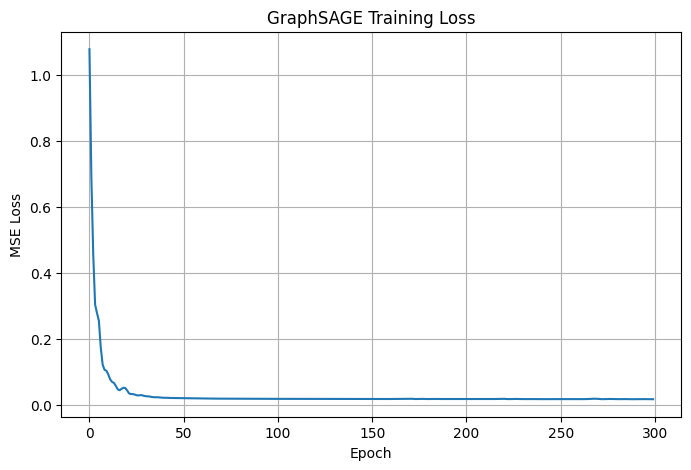

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "GraphSAGE Training Loss"
)

plt.grid()

plt.show()

In [34]:
model.eval()

with torch.no_grad():

    y_pred_graph = model(
        graph_data.x,
        graph_data.edge_index
    )


print("Prediction Shape:")
print(y_pred_graph.shape)

Prediction Shape:
torch.Size([500, 5])


In [35]:
test_predictions = y_pred_graph[
    graph_data.test_mask
]


test_actual = graph_data.y[
    graph_data.test_mask
]


print(test_predictions.shape)
print(test_actual.shape)

torch.Size([100, 5])
torch.Size([100, 5])


In [36]:
test_predictions_original = scaler_Y.inverse_transform(
    test_predictions.cpu().numpy()
)


test_actual_original = scaler_Y.inverse_transform(
    test_actual.cpu().numpy()
)


print(test_predictions_original[:5])

[[  6.0617375    7.985038   241.9172       2.2250593    0.7253512 ]
 [  6.0810885    7.9848094  241.57727      2.220874     0.7234017 ]
 [  6.2554603    7.9849615  239.2729       2.1279187    0.6848276 ]
 [  6.3236923    7.988592   238.41298      2.082546     0.6670039 ]
 [  6.514313     7.9977727  235.27711      1.977329     0.62622464]]


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae_gnn = mean_absolute_error(
    test_actual_original,
    test_predictions_original
)


rmse_gnn = np.sqrt(
    mean_squared_error(
        test_actual_original,
        test_predictions_original
    )
)


r2_gnn = r2_score(
    test_actual_original,
    test_predictions_original
)


print("GraphSAGE Spatial GNN")
print("----------------------------")
print("MAE :", mae_gnn)
print("RMSE:", rmse_gnn)
print("R²  :", r2_gnn)

GraphSAGE Spatial GNN
----------------------------
MAE : 0.6798752546310425
RMSE: 1.7984937591105086
R²  : 0.9821760058403015


In [38]:
target_result = []

for i, name in enumerate(target_cols):

    mae = mean_absolute_error(
        test_actual_original[:,i],
        test_predictions_original[:,i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_actual_original[:,i],
            test_predictions_original[:,i]
        )
    )

    r2 = r2_score(
        test_actual_original[:,i],
        test_predictions_original[:,i]
    )


    target_result.append(
        [
            name,
            mae,
            rmse,
            r2
        ]
    )


gnn_parameter_results = pd.DataFrame(
    target_result,
    columns=[
        "Water Quality Parameter",
        "MAE",
        "RMSE",
        "R2"
    ]
)


gnn_parameter_results

,Water Quality Parameter,MAE,RMSE,R2
0,Dissolved oxygen (mg/L),0.126690,0.158413,0.958733
1,Potential of Hydrogen (pH),0.028954,0.035113,0.975266
2,Total Dissolved Solids (mg/L),3.202544,4.018097,0.992664
3,Nitrate N (mgN/L),0.028952,0.035306,0.991283
4,Amonia N (mgN/L),0.012236,0.015196,0.992935


In [39]:
# Collect all model performance

model_comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "GraphSAGE Spatial GNN"
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mae_gnn
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        rmse_gnn
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_gnn
    ]

})


model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.239191,0.382819,0.883223
1,Random Forest,0.119687,0.158677,0.977838
2,XGBoost,0.120877,0.158046,0.978106
3,GraphSAGE Spatial GNN,0.679875,1.798494,0.982176


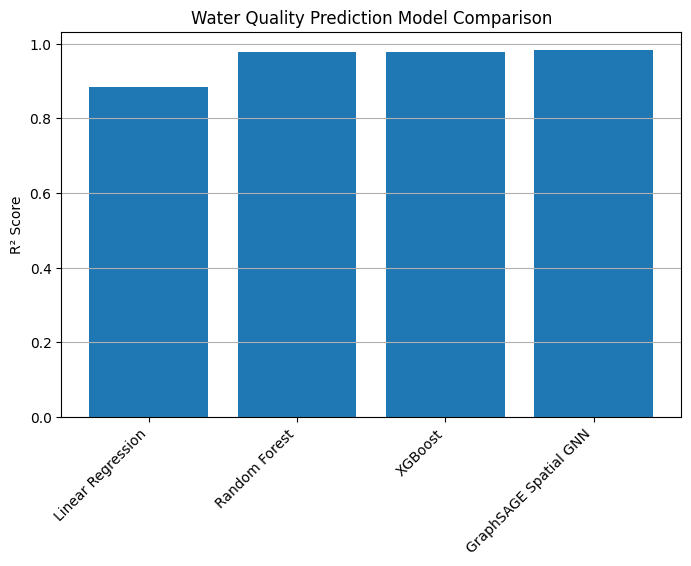

In [40]:
plt.figure(figsize=(8,5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2 Score"]
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.ylabel("R² Score")

plt.title(
    "Water Quality Prediction Model Comparison"
)

plt.grid(axis='y')

plt.show()

In [41]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})


importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)


importance_df

,Feature,Importance
6,GHSL_built_distance,0.308366
0,Latitude,0.204281
4,population_density,0.129283
2,River_distance_km,0.121928
1,Longitude,0.115780
5,river_discharge,0.066659
3,rainfall,0.033829
9,LULC_3,0.018498
8,LULC_2,0.000584
10,LULC_4,0.000437


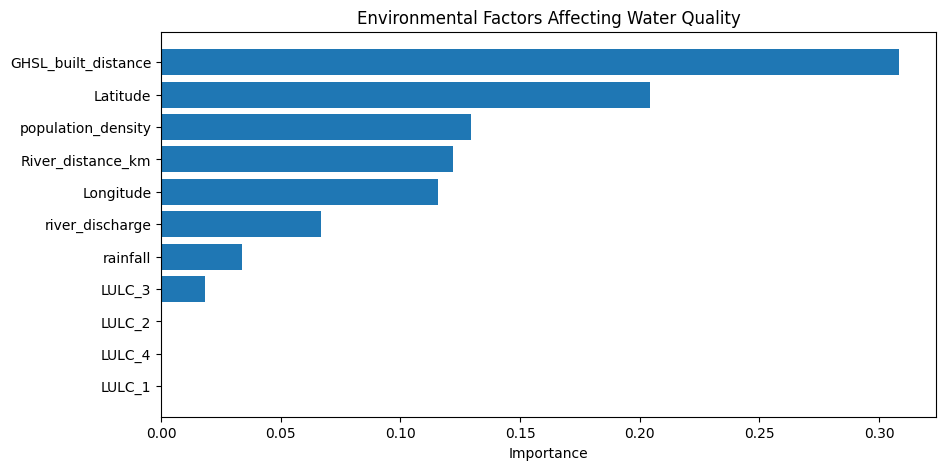

In [42]:
plt.figure(figsize=(10,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.title(
    "Environmental Factors Affecting Water Quality"
)

plt.gca().invert_yaxis()

plt.show()

In [43]:
import joblib


joblib.dump(
    rf_model,
    "RandomForest_WQ_Model.pkl"
)


joblib.dump(
    xgb_model,
    "XGBoost_WQ_Model.pkl"
)


joblib.dump(
    scaler_X,
    "Feature_Scaler.pkl"
)


joblib.dump(
    scaler_Y,
    "Target_Scaler.pkl"
)


torch.save(
    model.state_dict(),
    "GraphSAGE_WaterQuality_Model.pth"
)


print("Models saved successfully")

Models saved successfully


In [44]:
def predict_water_quality(
    latitude,
    longitude,
    river_distance,
    rainfall,
    population_density,
    lulc,
    river_discharge,
    ghsl_distance
):

    new_data = pd.DataFrame({

        "Latitude":[latitude],
        "Longitude":[longitude],
        "River_distance_km":[river_distance],
        "rainfall":[rainfall],
        "population_density":[population_density],
        "LULC":[lulc],
        "river_discharge":[river_discharge],
        "GHSL_built_distance":[ghsl_distance]

    })


    # encode LULC
    new_data = pd.get_dummies(
        new_data,
        columns=["LULC"]
    )


    # match training columns
    new_data = new_data.reindex(
        columns=X.columns,
        fill_value=0
    )


    new_scaled = scaler_X.transform(
        new_data
    )


    prediction_scaled = xgb_model.predict(
        new_scaled
    )


    prediction = scaler_Y.inverse_transform(
        prediction_scaled
    )


    return pd.DataFrame(
        prediction,
        columns=target_cols
    )

In [45]:
prediction = predict_water_quality(

    latitude=26.50,

    longitude=81.20,

    river_distance=100,

    rainfall=140,

    population_density=2000,

    lulc=3,

    river_discharge=3000,

    ghsl_distance=15

)


prediction

,Dissolved oxygen (mg/L),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Nitrate N (mgN/L),Amonia N (mgN/L)
0,7.726778,8.037731,230.636215,1.453999,0.309915


In [46]:
!pip install shap

In [47]:
import shap

import matplotlib.pyplot as plt

In [48]:
# Create SHAP explainer

explainer = shap.TreeExplainer(
    xgb_model
)


# Calculate SHAP values

shap_values = explainer.shap_values(
    X_test
)


print(type(shap_values))


<class 'numpy.ndarray'>


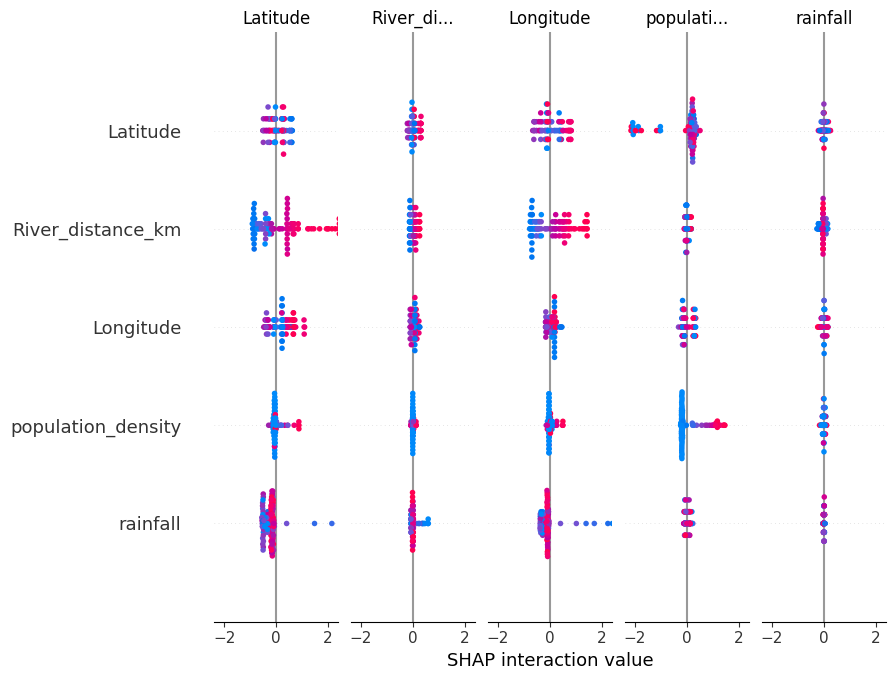

In [49]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

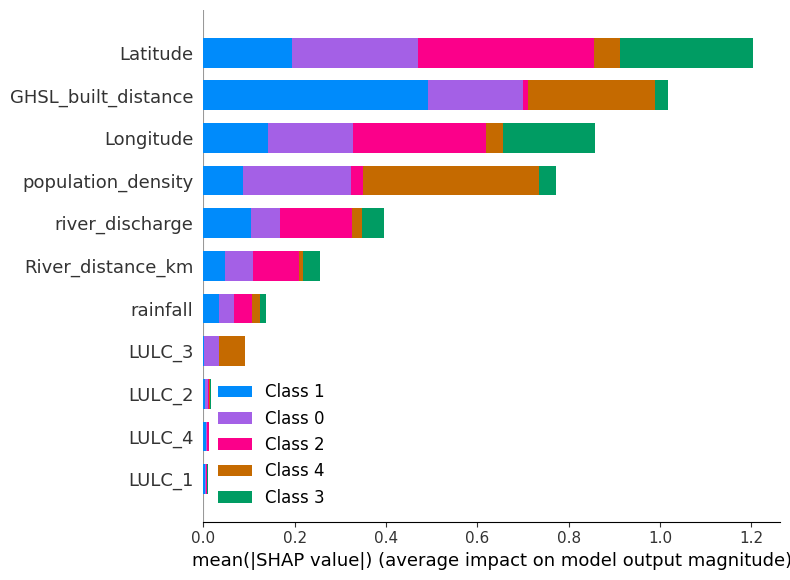

In [50]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

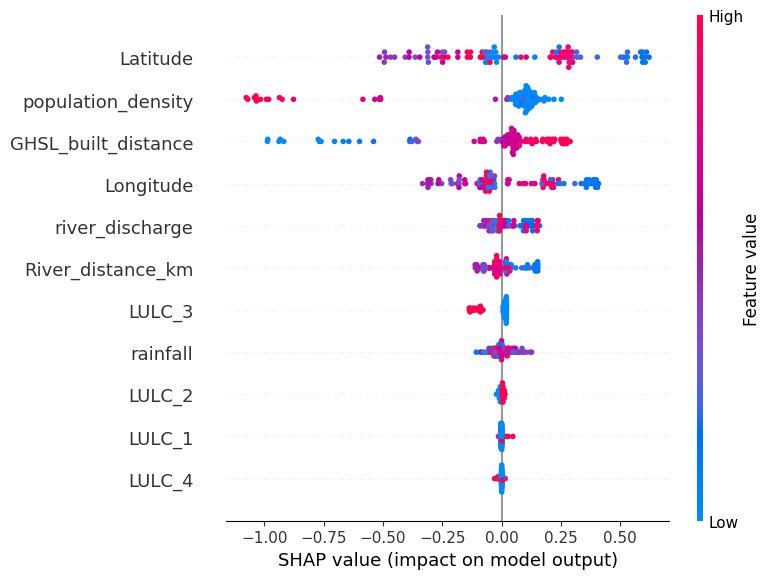

In [51]:
# DO explanation

shap.summary_plot(
    shap_values[:,:,0],
    X_test,
    feature_names=X.columns
)

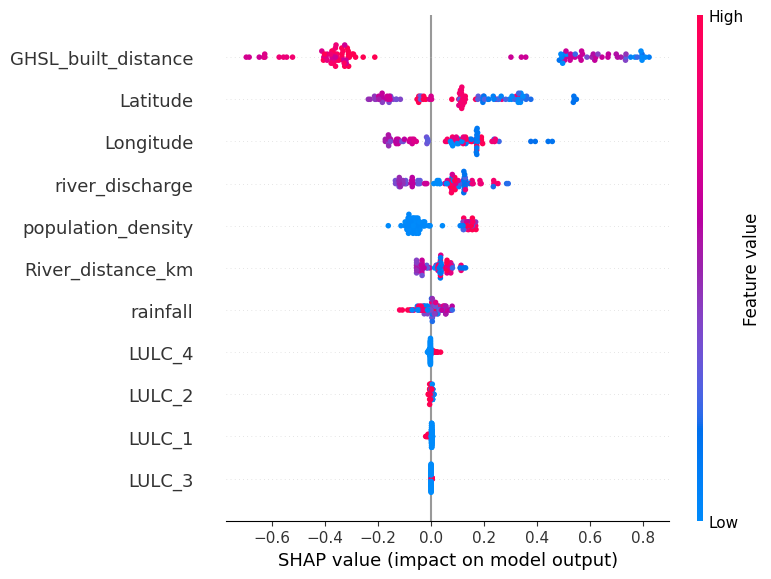

In [52]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    feature_names=X.columns
)

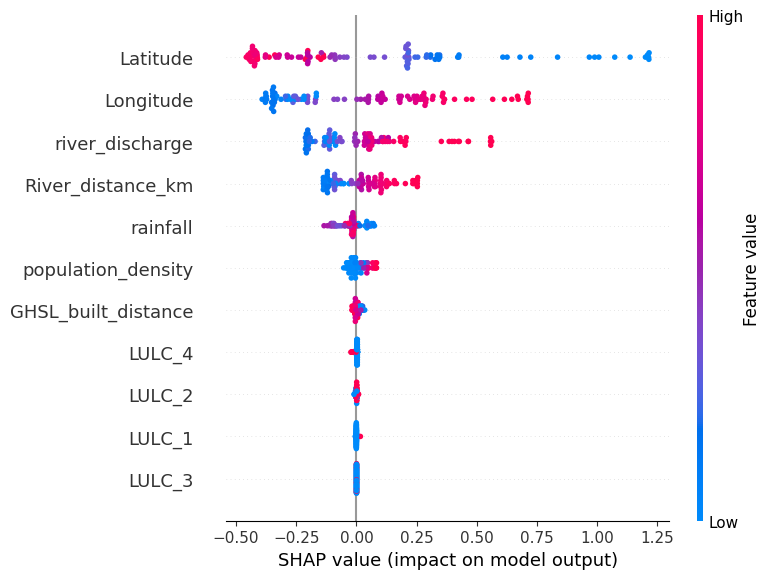

In [53]:
shap.summary_plot(
    shap_values[:,:,2],
    X_test,
    feature_names=X.columns
)

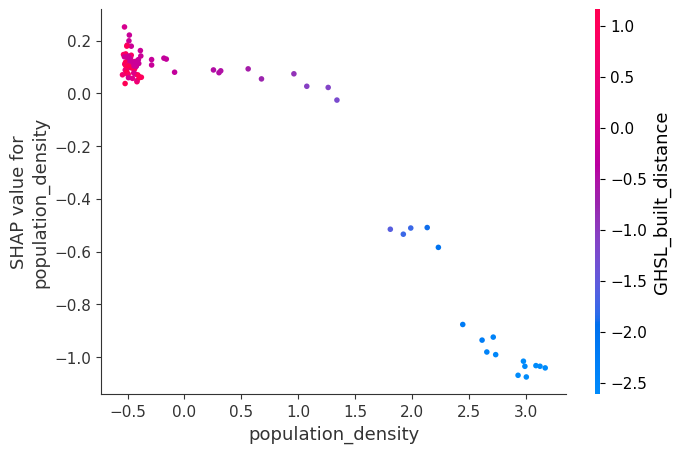

In [54]:
shap.dependence_plot(
    "population_density",
    shap_values[:,:,0],
    X_test,
    feature_names=X.columns
)

In [55]:
shap_importance = pd.DataFrame({

    "Feature": X.columns,

    "SHAP Importance": np.abs(
        shap_values
    ).mean(axis=0).mean(axis=1)

})


shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)


shap_importance

,Feature,SHAP Importance
0,Latitude,0.240461
6,GHSL_built_distance,0.203333
1,Longitude,0.171584
4,population_density,0.154526
5,river_discharge,0.078933
2,River_distance_km,0.051055
3,rainfall,0.027624
9,LULC_3,0.018096
8,LULC_2,0.003502
10,LULC_4,0.002695


In [56]:
shap_importance.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)

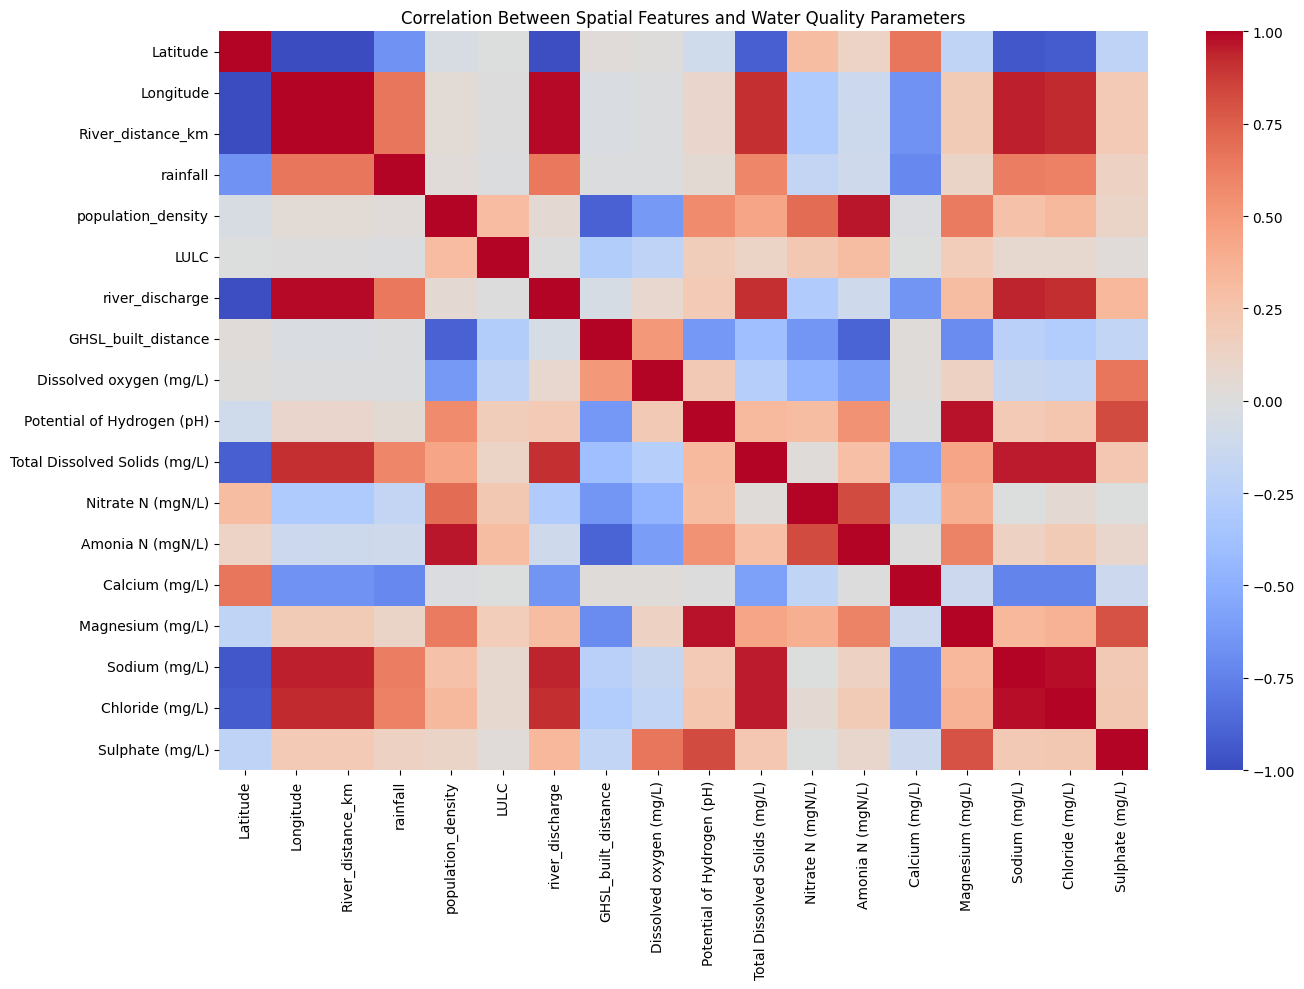

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)


sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Spatial Features and Water Quality Parameters"
)

plt.tight_layout()

plt.show()

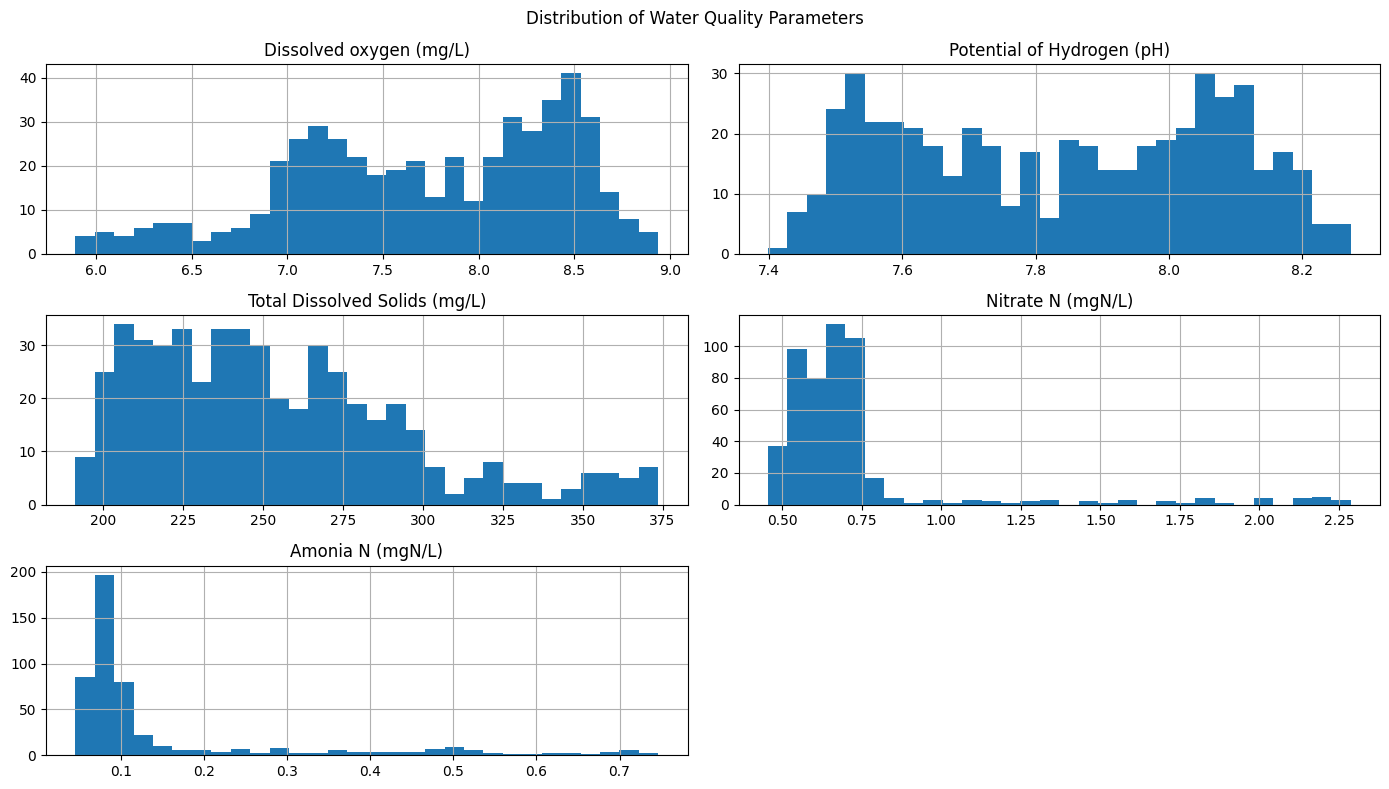

In [58]:
target_cols = [
    'Dissolved oxygen (mg/L)',
    'Potential of Hydrogen (pH)',
    'Total Dissolved Solids (mg/L)',
    'Nitrate N (mgN/L)',
    'Amonia N (mgN/L)'
]


df[target_cols].hist(
    figsize=(14,8),
    bins=30
)


plt.suptitle(
    "Distribution of Water Quality Parameters"
)

plt.tight_layout()

plt.show()

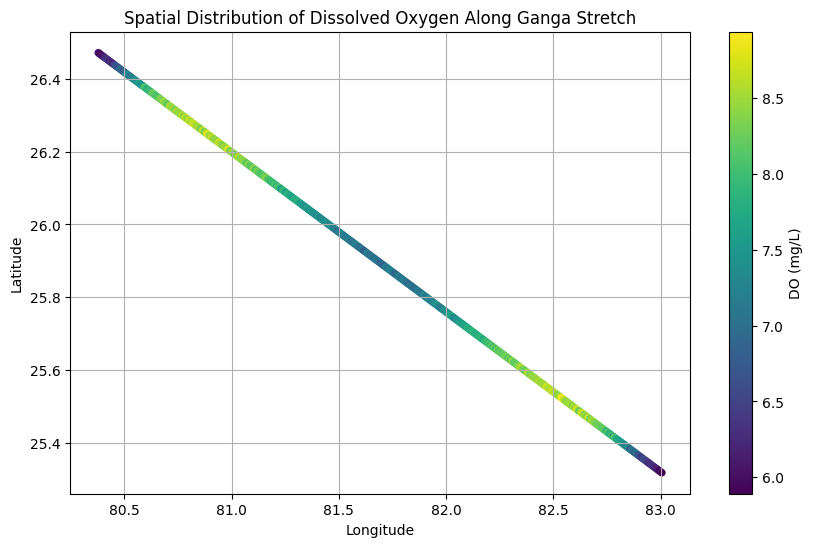

In [59]:
plt.figure(figsize=(10,6))


plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Dissolved oxygen (mg/L)"],
    cmap="viridis",
    s=20
)


plt.colorbar(
    label="DO (mg/L)"
)


plt.xlabel(
    "Longitude"
)

plt.ylabel(
    "Latitude"
)


plt.title(
    "Spatial Distribution of Dissolved Oxygen Along Ganga Stretch"
)


plt.grid()

plt.show()

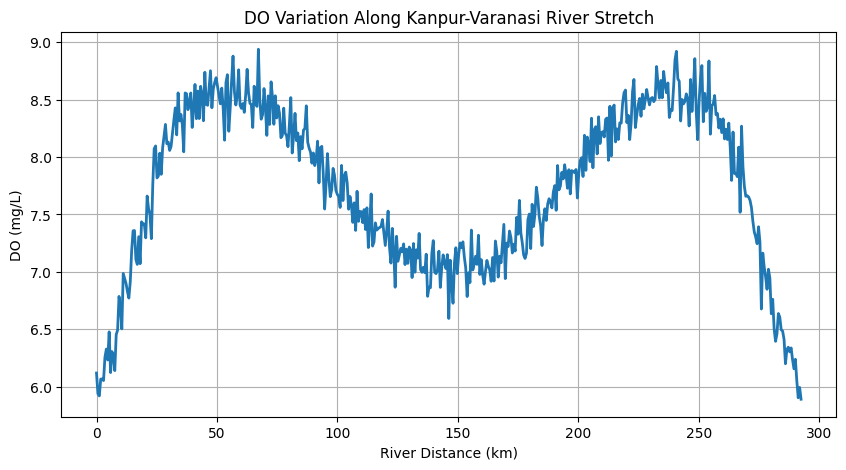

In [60]:
plt.figure(figsize=(10,5))


plt.plot(
    df["River_distance_km"],
    df["Dissolved oxygen (mg/L)"],
    linewidth=2
)


plt.xlabel(
    "River Distance (km)"
)

plt.ylabel(
    "DO (mg/L)"
)


plt.title(
    "DO Variation Along Kanpur-Varanasi River Stretch"
)


plt.grid()

plt.show()

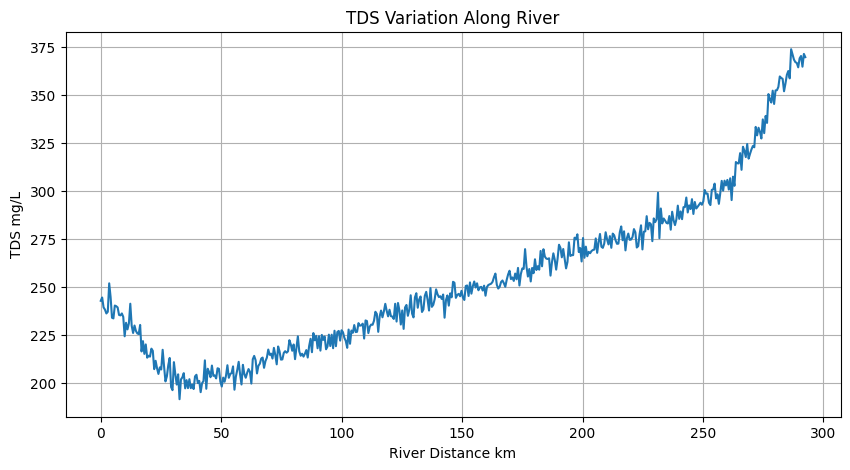

In [61]:
plt.figure(figsize=(10,5))


plt.plot(
    df["River_distance_km"],
    df["Total Dissolved Solids (mg/L)"]
)


plt.xlabel("River Distance km")

plt.ylabel("TDS mg/L")


plt.title(
    "TDS Variation Along River"
)


plt.grid()

plt.show()

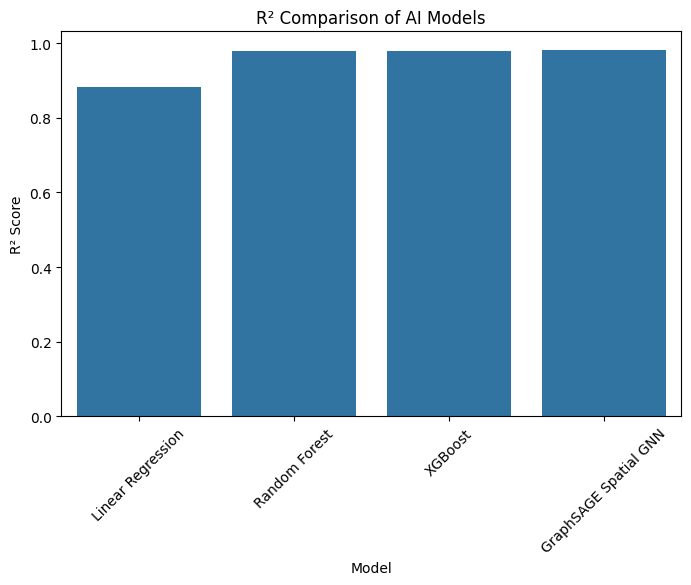

In [62]:
plt.figure(figsize=(8,5))


sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2 Score"
)


plt.xticks(
    rotation=45
)


plt.title(
    "R² Comparison of AI Models"
)


plt.ylabel(
    "R² Score"
)


plt.show()

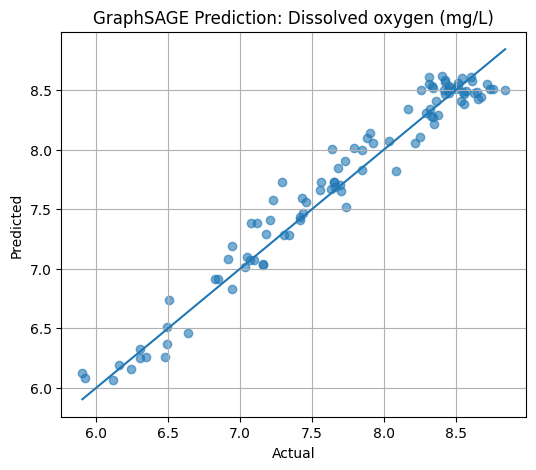

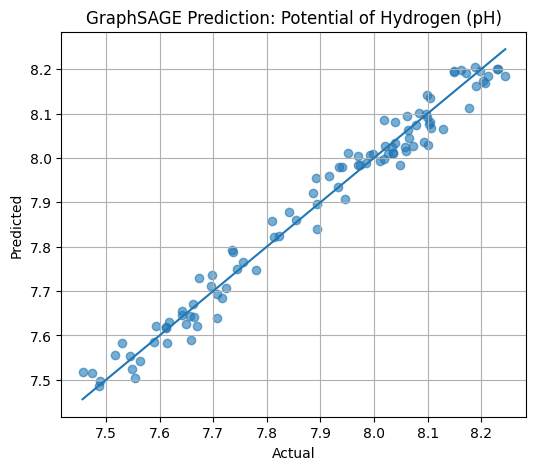

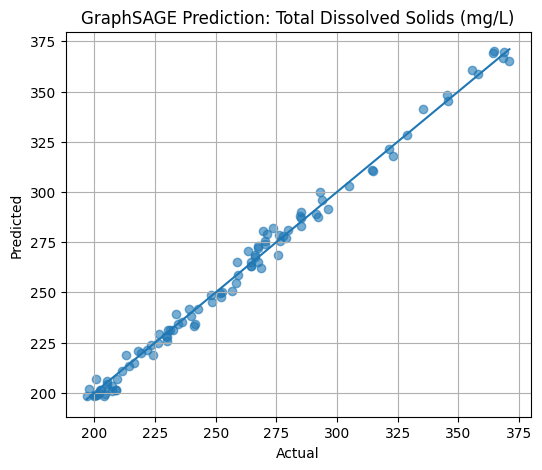

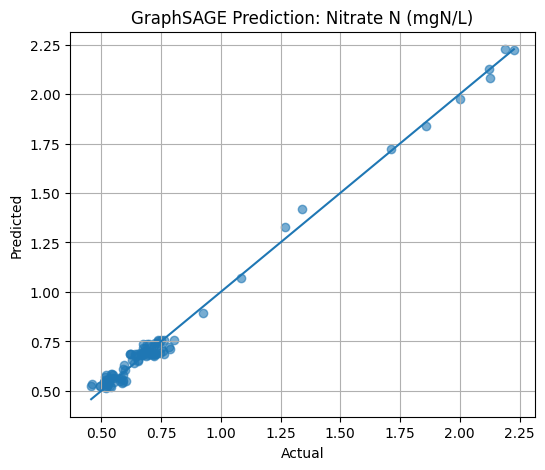

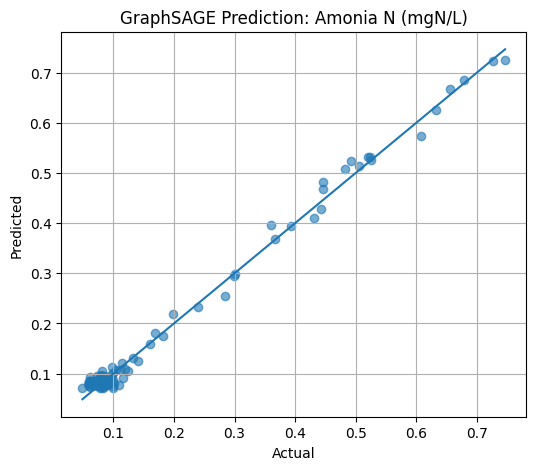

In [63]:
for i,name in enumerate(target_cols):

    plt.figure(figsize=(6,5))


    plt.scatter(
        test_actual_original[:,i],
        test_predictions_original[:,i],
        alpha=0.6
    )


    plt.plot(
        [
            test_actual_original[:,i].min(),
            test_actual_original[:,i].max()
        ],
        [
            test_actual_original[:,i].min(),
            test_actual_original[:,i].max()
        ]
    )


    plt.xlabel(
        "Actual"
    )

    plt.ylabel(
        "Predicted"
    )


    plt.title(
        f"GraphSAGE Prediction: {name}"
    )


    plt.grid()

    plt.show()

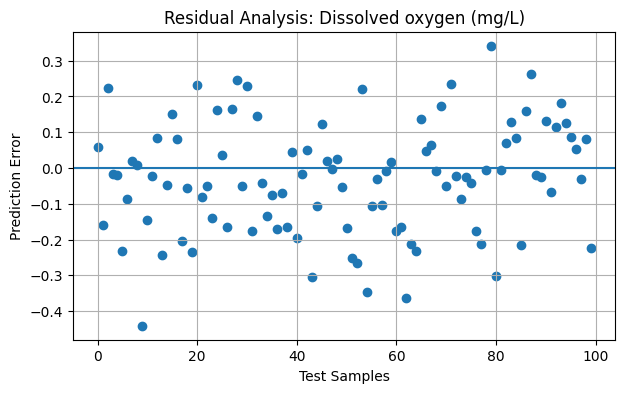

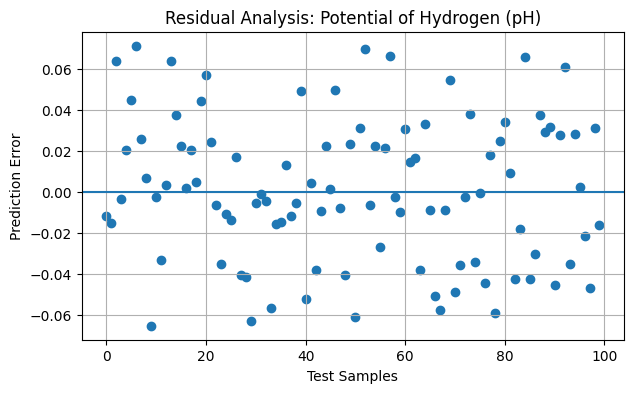

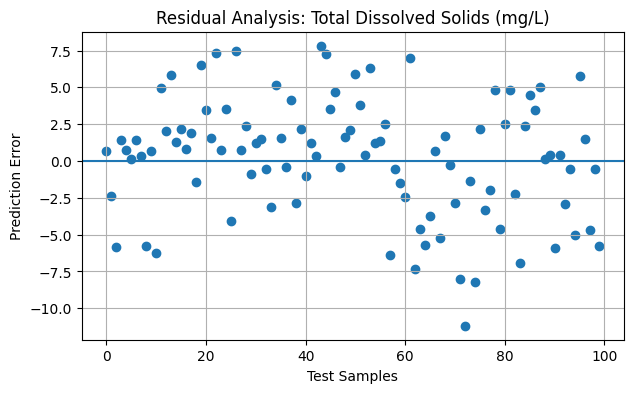

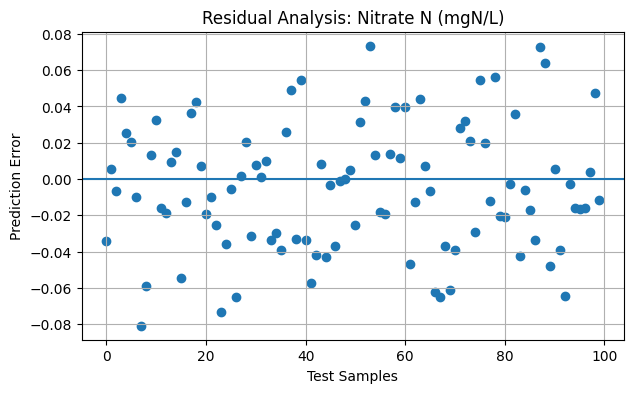

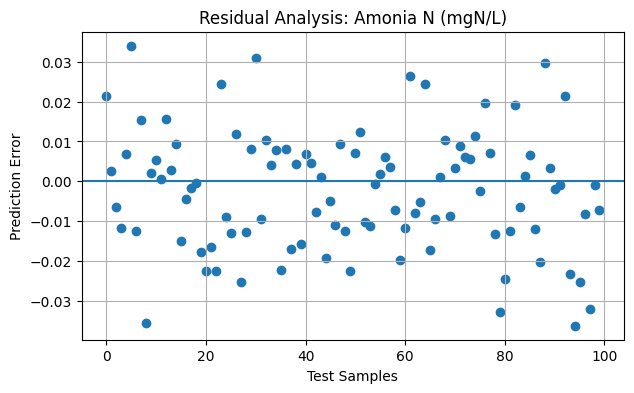

In [64]:
for i,name in enumerate(target_cols):

    residual = (
        test_actual_original[:,i]
        -
        test_predictions_original[:,i]
    )


    plt.figure(figsize=(7,4))


    plt.scatter(
        range(len(residual)),
        residual
    )


    plt.axhline(
        0
    )


    plt.xlabel(
        "Test Samples"
    )

    plt.ylabel(
        "Prediction Error"
    )


    plt.title(
        f"Residual Analysis: {name}"
    )


    plt.grid()

    plt.show()

In [65]:
df.to_csv(
    "Final_Ganga_Multimodal_Spatial_WQ.csv",
    index=False
)


print(
    "Final dataset saved"
)

Final dataset saved


In [66]:
torch.save(
    graph_data,
    "Ganga_Spatial_Graph.pt"
)


print(
    "Graph saved"
)

Graph saved


In [67]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_features": X.columns.tolist(),
        "target_columns": target_cols
    },
    "GraphSAGE_Ganga_WQ_Model.pth"
)


print(
    "GraphSAGE model saved"
)

GraphSAGE model saved
